In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
from torch.nn import CrossEntropyLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

from torchvision.transforms import RandomRotation, RandomHorizontalFlip, ColorJitter

# Set device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define dataset path
dataset_path = "/content/drive/MyDrive/image with free"  # Update this path

Using device: cuda


In [ ]:
# Import required libraries
import torchvision.transforms as transforms

# Define augmentations
augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(size=(224, 224), scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Print to verify it works
print("Augmentation pipeline defined successfully!")


Augmentation pipeline defined successfully!


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import numpy as np
from collections import defaultdict

# -------------------------------
# 1. Define Transforms
# -------------------------------

# Transform برای Validation / Test
base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Augmentation فقط برای Train
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.2, hue=0.1),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# -------------------------------
# 2. Load dataset (initial transform)
# -------------------------------
dataset_path = "/content/drive/MyDrive/image with free"
dataset = datasets.ImageFolder(root=dataset_path, transform=base_transform)

# -------------------------------
# 3. Stratified split
# -------------------------------
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15

class_indices = defaultdict(list)

# جمع کردن اندیس‌های هر کلاس
for idx, (_, label) in enumerate(dataset):
    class_indices[label].append(idx)

train_idx, val_idx, test_idx = [], [], []

# تقسیم برای هر کلاس
for cls, indices in class_indices.items():
    np.random.shuffle(indices)
    n_total = len(indices)

    n_test = max(1, int(test_ratio * n_total))
    remaining = n_total - n_test

    n_train = int(train_ratio / (train_ratio + val_ratio) * remaining)
    n_val = remaining - n_train

    train_idx.extend(indices[:n_train])
    val_idx.extend(indices[n_train:n_train + n_val])
    test_idx.extend(indices[n_train + n_val : n_train + n_val + n_test])

# -------------------------------
# 4. Create subsets
# -------------------------------
train_dataset = Subset(dataset, train_idx)
val_dataset = Subset(dataset, val_idx)
test_dataset = Subset(dataset, test_idx)

# -------------------------------
# 5. Assign transforms separately
# -------------------------------
# فقط Train → augmentation
train_dataset.dataset.transform = train_transform

# Val & Test → بدون augmentation
val_dataset.dataset.transform = base_transform
test_dataset.dataset.transform = base_transform

# -------------------------------
# 6. DataLoaders
# -------------------------------
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

print(" Stratified split + augmentation DONE!")
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))


 Stratified split + augmentation DONE!
Train samples: 8784
Val samples: 1888
Test samples: 1879


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the pretrained ResNet50 model
model = models.resnet50(weights="IMAGENET1K_V1")

# Freeze all layers initially
for param in model.parameters():
    param.requires_grad = False

# Unfreeze specific layers for fine-tuning (e.g., layer3 and layer4)
for param in model.layer3.parameters():
    param.requires_grad = True
for param in model.layer4.parameters():
    param.requires_grad = True

# Modify the final fully connected layer to match the number of classes
num_classes = 10  # Adjust this based on your dataset
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes)  # Removed LogSoftmax
)

# Move the model to the device
model = model.to(device)

# Define class weights (adjust as necessary for your dataset)
class_weights = torch.tensor([1.0, 2.0, 1.5, 0.8, 1.2, 1.8, 1.0, 0.9, 1.3, 2.5]).to(device)

# Define the loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Define the optimizer (only for the unfrozen layers and the classifier)
optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-4},  # Fine-tuning layers with lower learning rate
    {'params': model.layer4.parameters(), 'lr': 1e-4},  # Fine-tuning layers with lower learning rate
    {'params': model.fc.parameters(), 'lr': 1e-3}       # Higher learning rate for the classifier
], weight_decay=1e-4)

# Define the learning rate scheduler
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

print("Model and training components are defined successfully.")


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 138MB/s]


Model and training components are defined successfully.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models
from torch.utils.data import DataLoader
import os

# -------------------------------------------------
# 1. CUDA Optimization
# -------------------------------------------------
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -------------------------------------------------
# 2. Load pretrained ResNet50
# -------------------------------------------------
model = models.resnet50(weights="IMAGENET1K_V1")

# Freeze all layers
for p in model.parameters():
    p.requires_grad = False

# Unfreeze layer3 and layer4 for fine-tuning
for p in model.layer3.parameters():
    p.requires_grad = True
for p in model.layer4.parameters():
    p.requires_grad = True

# Modify the classifier (FC layer)
num_classes = 10
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024),
    nn.ReLU(),
    nn.GroupNorm(32, 1024), 
    nn.Linear(1024, num_classes)  
)

model = model.to(device)

# -------------------------------------------------
# 3. Loss, Optimizer, Scheduler
# -------------------------------------------------
class_weights = torch.tensor([1,2,1.5,0.8,1.2,1.8,1,0.9,1.3,2.5]).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = optim.Adam([
    {'params': model.layer3.parameters(), 'lr': 1e-4},
    {'params': model.layer4.parameters(), 'lr': 1e-4},
    {'params': model.fc.parameters(), 'lr': 1e-3}
], weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    patience=3,
    factor=0.3
)

# -------------------------------------------------
# 4. DataLoader
# -------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=True
)

# -------------------------------------------------
# 5. Checkpoint Resume
# -------------------------------------------------
checkpoint_path = "/content/drive/MyDrive/checkpoint_resnet50.pth"
start_epoch = 0
best_val_accuracy = 0.0

if os.path.exists(checkpoint_path):
    print(" Loading checkpoint...")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    start_epoch = checkpoint["epoch"] + 1
    best_val_accuracy = checkpoint["best_val_accuracy"]
    print(f"✔ Resumed from epoch {start_epoch}, best_val_accuracy = {best_val_accuracy:.2f}%")
else:
    print("Starting from scratch...")

# -------------------------------------------------
# 6. AMP setup
# -------------------------------------------------
scaler = torch.cuda.amp.GradScaler()

# -------------------------------------------------
# 7. Training Loop
# -------------------------------------------------
num_epochs = 50

for epoch in range(start_epoch, num_epochs):
    print(f"\n🔵 Epoch {epoch + 1}/{num_epochs}")

    # ---------------- Training ----------------
    model.train()
    train_loss = 0
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast(device_type='cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = 100 * correct_train / total_train

    # ---------------- Validation ----------------
    model.eval()
    val_loss = 0
    correct_val = 0
    total_val = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_acc = 100 * correct_val / total_val
    val_loss /= len(val_loader)

    # Scheduler
    scheduler.step(val_loss)

    print(f"Train Loss = {train_loss / len(train_loader):.4f}, "
          f"Train Acc = {train_acc:.2f}%, "
          f"Val Loss = {val_loss:.4f}, Val Acc = {val_acc:.2f}%")

    # Save best model
    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_resnet50_model.pth")
        print("🌟 Best model updated!")

    # Save checkpoint
    torch.save({
        "epoch": epoch,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
        "best_val_accuracy": best_val_accuracy
    }, checkpoint_path)
    print("💾 Checkpoint saved.")


Using device: cuda
Starting from scratch...

🔵 Epoch 1/50


/tmp/ipython-input-2943932013.py:105: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


Train Loss = 0.7861, Train Acc = 74.82%, Val Loss = 0.3201, Val Acc = 90.78%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 2/50
Train Loss = 0.4687, Train Acc = 85.03%, Val Loss = 0.4388, Val Acc = 88.03%
💾 Checkpoint saved.

🔵 Epoch 3/50
Train Loss = 0.3733, Train Acc = 88.40%, Val Loss = 0.4069, Val Acc = 89.19%
💾 Checkpoint saved.

🔵 Epoch 4/50
Train Loss = 0.3020, Train Acc = 90.84%, Val Loss = 0.4114, Val Acc = 87.18%
💾 Checkpoint saved.

🔵 Epoch 5/50
Train Loss = 0.2504, Train Acc = 92.43%, Val Loss = 0.3787, Val Acc = 90.73%
💾 Checkpoint saved.

🔵 Epoch 6/50
Train Loss = 0.0948, Train Acc = 96.80%, Val Loss = 0.2010, Val Acc = 94.33%
🌟 Best model updated!
💾 Checkpoint saved.

🔵 Epoch 7/50
Train Loss = 0.0590, Train Acc = 98.13%, Val Loss = 0.2370, Val Acc = 94.01%
💾 Checkpoint saved.

🔵 Epoch 8/50
Train Loss = 0.0541, Train Acc = 98.36%, Val Loss = 0.2375, Val Acc = 94.07%
💾 Checkpoint saved.

🔵 Epoch 9/50
Train Loss = 0.0483, Train Acc = 98.55%, Val Loss = 0.2633, Val Acc 

In [18]:
import torch
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import os

# -----------------------------
# 🔹 1. تعریف کلاس‌ها
# -----------------------------
class_names = [
    'Rbc', 'Wbc', 'acid uric', 'amorph urate', 'bacteria',
    'caox', 'ep', 'fungi', 'sperm', 'triple'
]

save_dir = "/content/drive/MyDrive/results_cm"
os.makedirs(save_dir, exist_ok=True)

# -----------------------------
# 🔹 2. پیش‌بینی روی داده‌های تست
# -----------------------------
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# -----------------------------
# 🔹 3. ساخت ماتریس سردرگمی
# -----------------------------
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))

# ماتریس درصدی واقعی در هر ردیف
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_percent = np.nan_to_num(cm_percent) * 100   # درصد

# -----------------------------
# 🔹 4. رسم CM درصدی (اصلی)
# -----------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_percent,
    annot=True, fmt=".2f",
    cmap="Purples",
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Normalized (%)")
plt.tight_layout()
plt.savefig(f"{save_dir}/CM_percent.png", dpi=300)
plt.show()

# -----------------------------
# 🔹 5. رسم CM خام 
# -----------------------------
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True, fmt="d",
    cmap="Blues",
    xticklabels=class_names, yticklabels=class_names
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix - Counts")
plt.tight_layout()
plt.savefig(f"{save_dir}/CM_counts.png", dpi=300)
plt.show()

# -----------------------------
# 🔹 6. گزارش کامل کلاس‌ها
# -----------------------------
report = classification_report(
    y_true, y_pred,
    target_names=class_names,
    digits=4
)

print("\n====================== CLASSIFICATION REPORT ======================\n")
print(report)

with open(f"{save_dir}/classification_report.txt", "w") as f:
    f.write(report)

print(f"\n📁 فایل‌ها ذخیره شدند در: {save_dir}")


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

In [ ]:
# Evaluate the model on the test set
model.eval()
test_loss = 0.0
correct_test = 0
total_test = 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs, 1)
        correct_test += (predicted == labels).sum().item()
        total_test += labels.size(0)

test_loss /= total_test
test_accuracy = 100 * correct_test / total_test
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%")

torch.save(model.state_dict(), "best_model_test.pth")
print("Model saved successfully!")


Test Loss: 0.2980, Test Accuracy: 94.94%
Model saved successfully!


In [ ]:
import torch
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import time

def evaluate_model_performance(model, test_loader, classes):
    model.eval()
    y_true = []
    y_pred = []
    start_time = time.time()

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            y_true.extend(labels.cpu().numpy())
            y_pred.extend(predicted.cpu().numpy())

    # زمان پایان
    end_time = time.time()
    calculation_time = end_time - start_time

    # محاسبه معیارها
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    # نمایش نتایج
    print("Evaluation Results:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall (Sensitivity): {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Calculation Time: {calculation_time:.2f} seconds")



    return accuracy, precision, recall, f1, calculation_time

# فراخوانی تابع برای ارزیابی
classes = ["'Rbc', 'Wbc', 'acid uric', 'amorph urate', 'bacteria', 'caox', 'ep', 'fungi', 'sperm', 'triple'"]  
evaluate_model_performance(model, test_loader, classes)



In [19]:
from PIL import Image
import torchvision.transforms as transforms
import torch
import matplotlib.pyplot as plt
from torchvision import models
import torch.nn as nn
import os

# -----------------------------
# 1. Device
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# -----------------------------
# 2. Load the trained ResNet50 model
# -----------------------------
num_classes = 10
model = models.resnet50(pretrained=False)

# Customize classifier
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 1024),
    nn.ReLU(),
    nn.BatchNorm1d(1024),
    nn.Dropout(0.5),
    nn.Linear(1024, num_classes),
    nn.LogSoftmax(dim=1)
)

# Load saved weights
model_path = "/content/drive/MyDrive/best_resnet50_model.pth"  # مسیر مدل
if not os.path.exists(model_path):
    raise FileNotFoundError(f"Model not found at {model_path}")

model.load_state_dict(torch.load(model_path, map_location=device))
model = model.to(device)
model.eval()
print("Model loaded successfully")

# -----------------------------
# 3. Image preprocessing
# -----------------------------
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# -----------------------------
# 4. Function to test a single image
# -----------------------------
class_names = ['Rbc', 'Wbc', 'acid uric', 'amorph urate', 'bacteria',
               'caox', 'ep', 'fungi', 'sperm', 'triple']

def test_single_image(image_path):
    if not os.path.exists(image_path):
        raise FileNotFoundError(f"Image not found at {image_path}")

    # Load and preprocess the image
    image = Image.open(image_path).convert("RGB")
    input_tensor = preprocess(image).unsqueeze(0).to(device)

    # Model inference
    with torch.no_grad():
        output = model(input_tensor)
        _, predicted_class = torch.max(output, 1)

    predicted_class_name = class_names[predicted_class.item()]
    return predicted_class_name, image

# -----------------------------
# 5. Test on an example image
# -----------------------------
image_path = "/content/drive/MyDrive/12_Wbc_27_1146_superres.jpg"
predicted_class_name, image = test_single_image(image_path)

# Display the result
plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title(f"Predicted Class: {predicted_class_name}")
plt.axis("off")
plt.show()


Using device: cuda


RuntimeError: Error(s) in loading state_dict for ResNet:
	Missing key(s) in state_dict: "fc.2.running_mean", "fc.2.running_var". 

/tmp/ipython-input-3055542018.py:18: RuntimeWarning: invalid value encountered in divide
  cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True)


Saved: /content/drive/MyDrive/results_cm/CM_counts.png /content/drive/MyDrive/results_cm/CM_percent.png


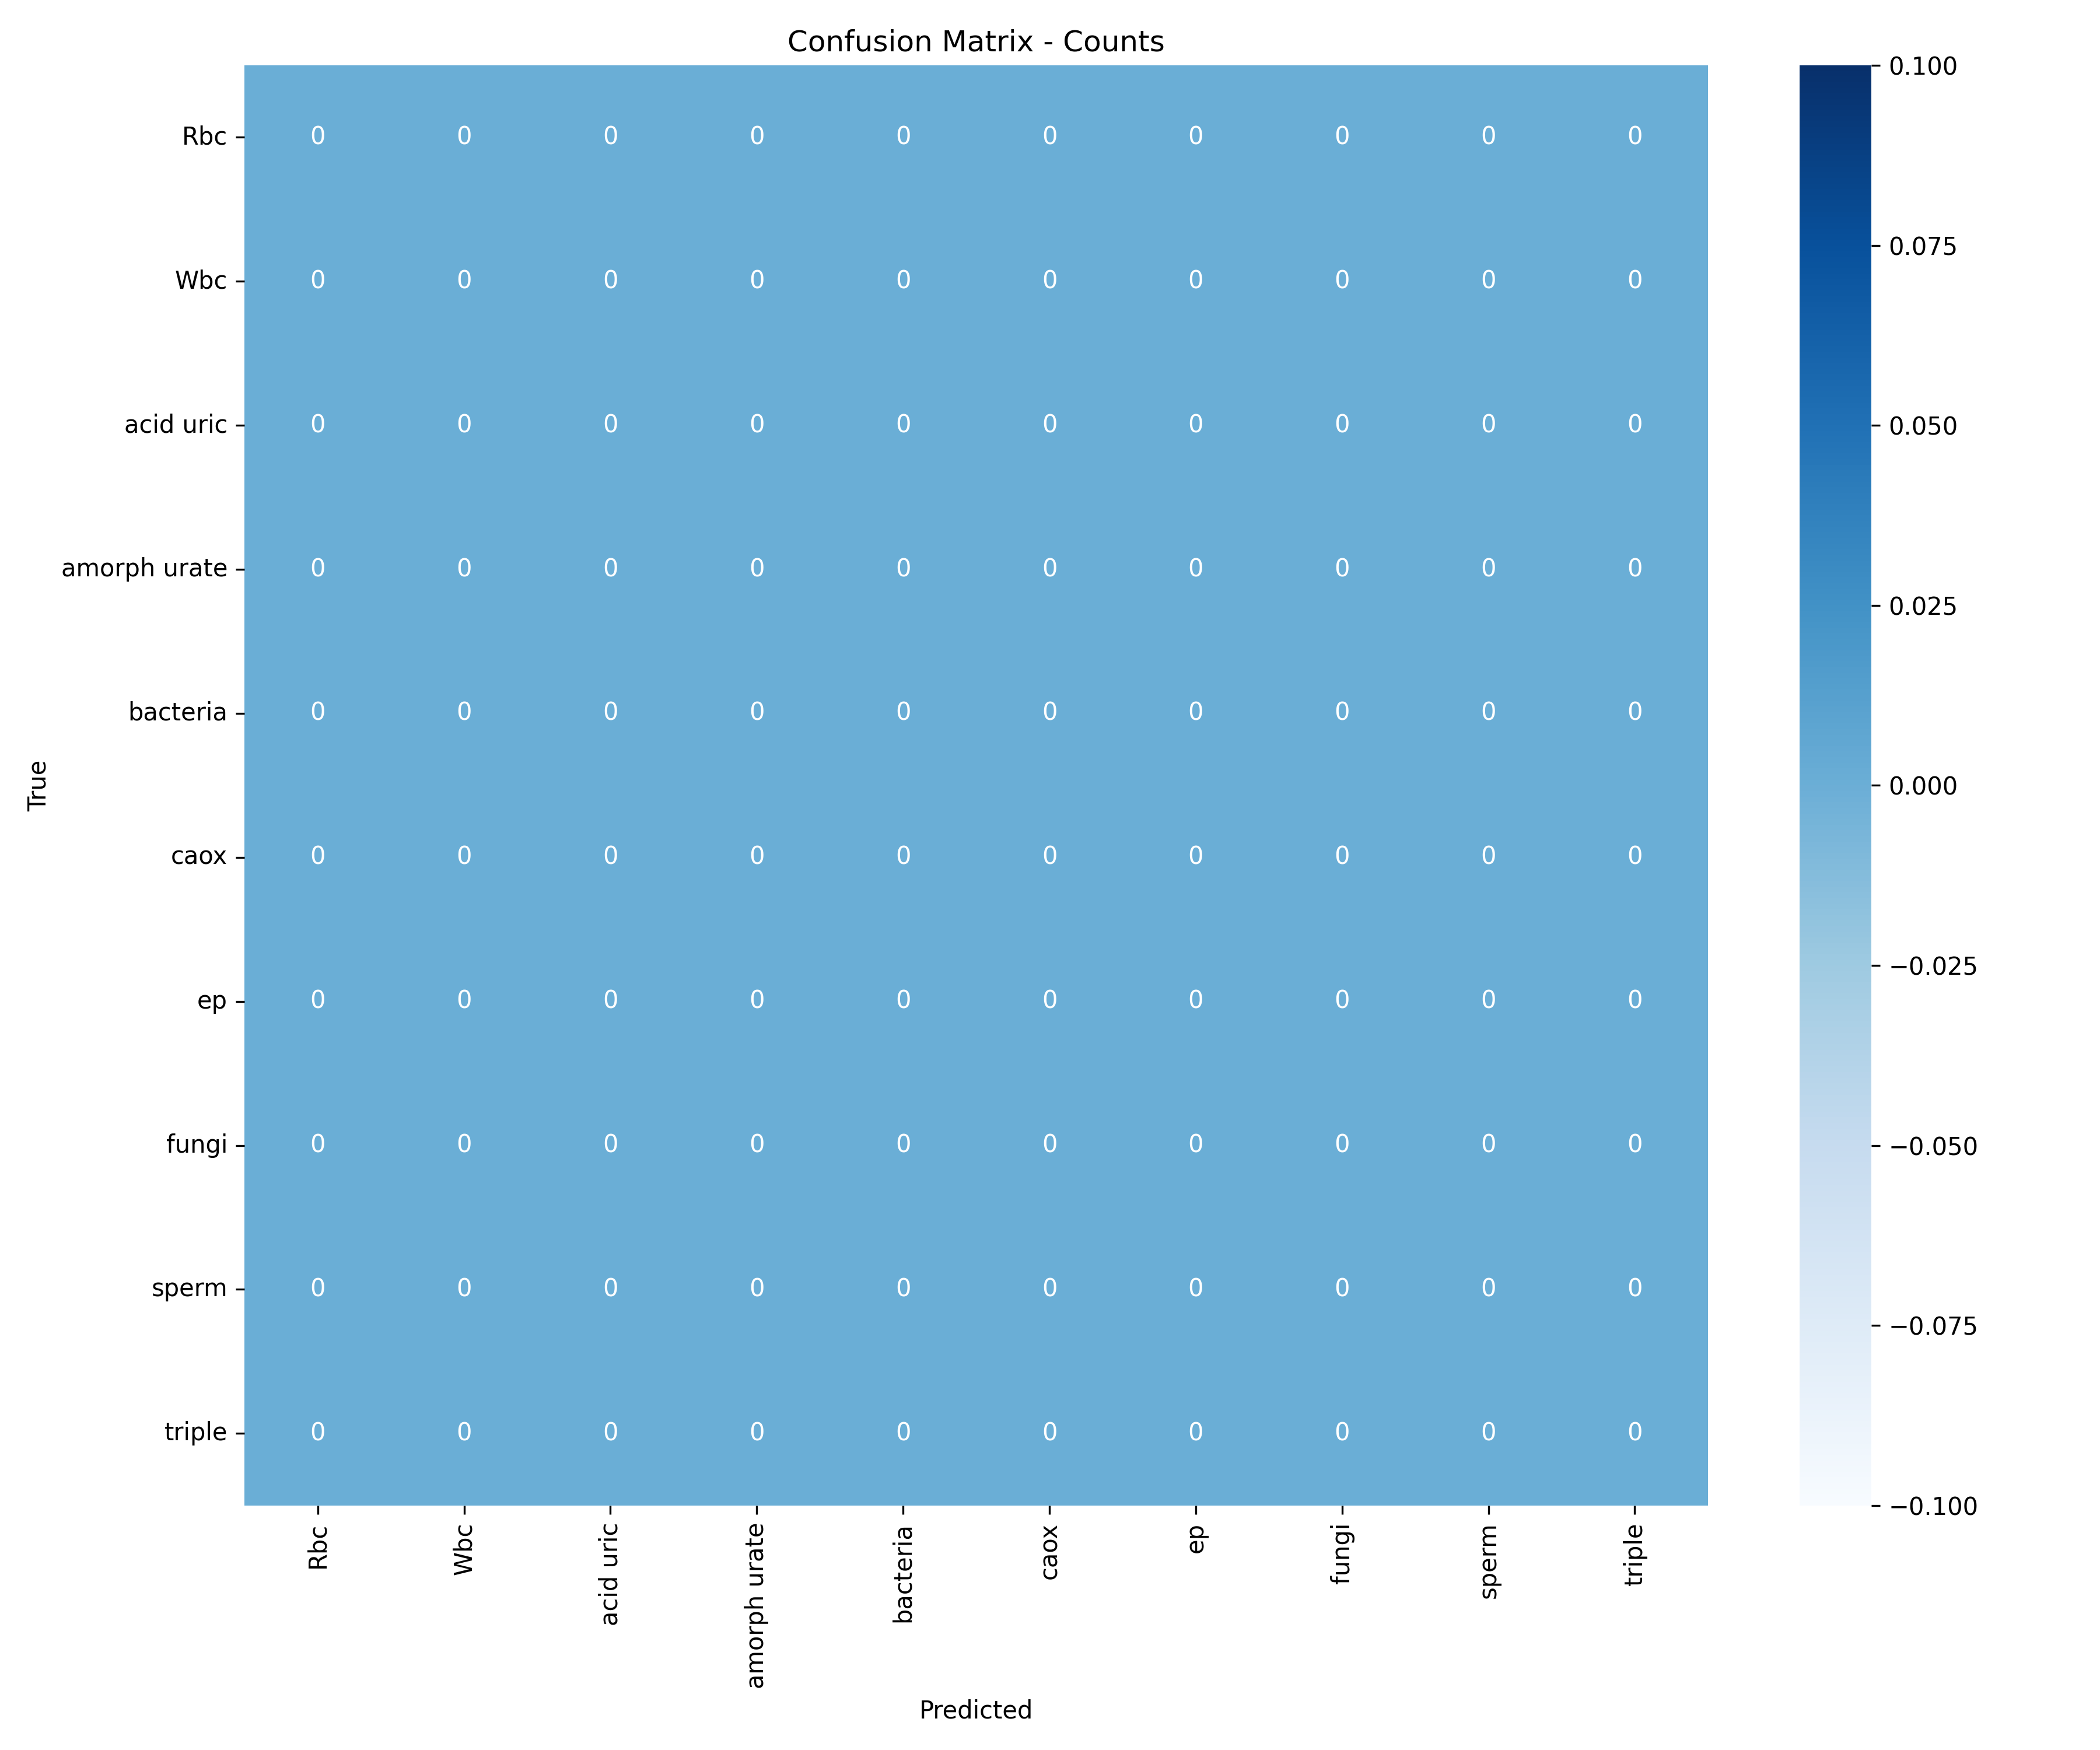

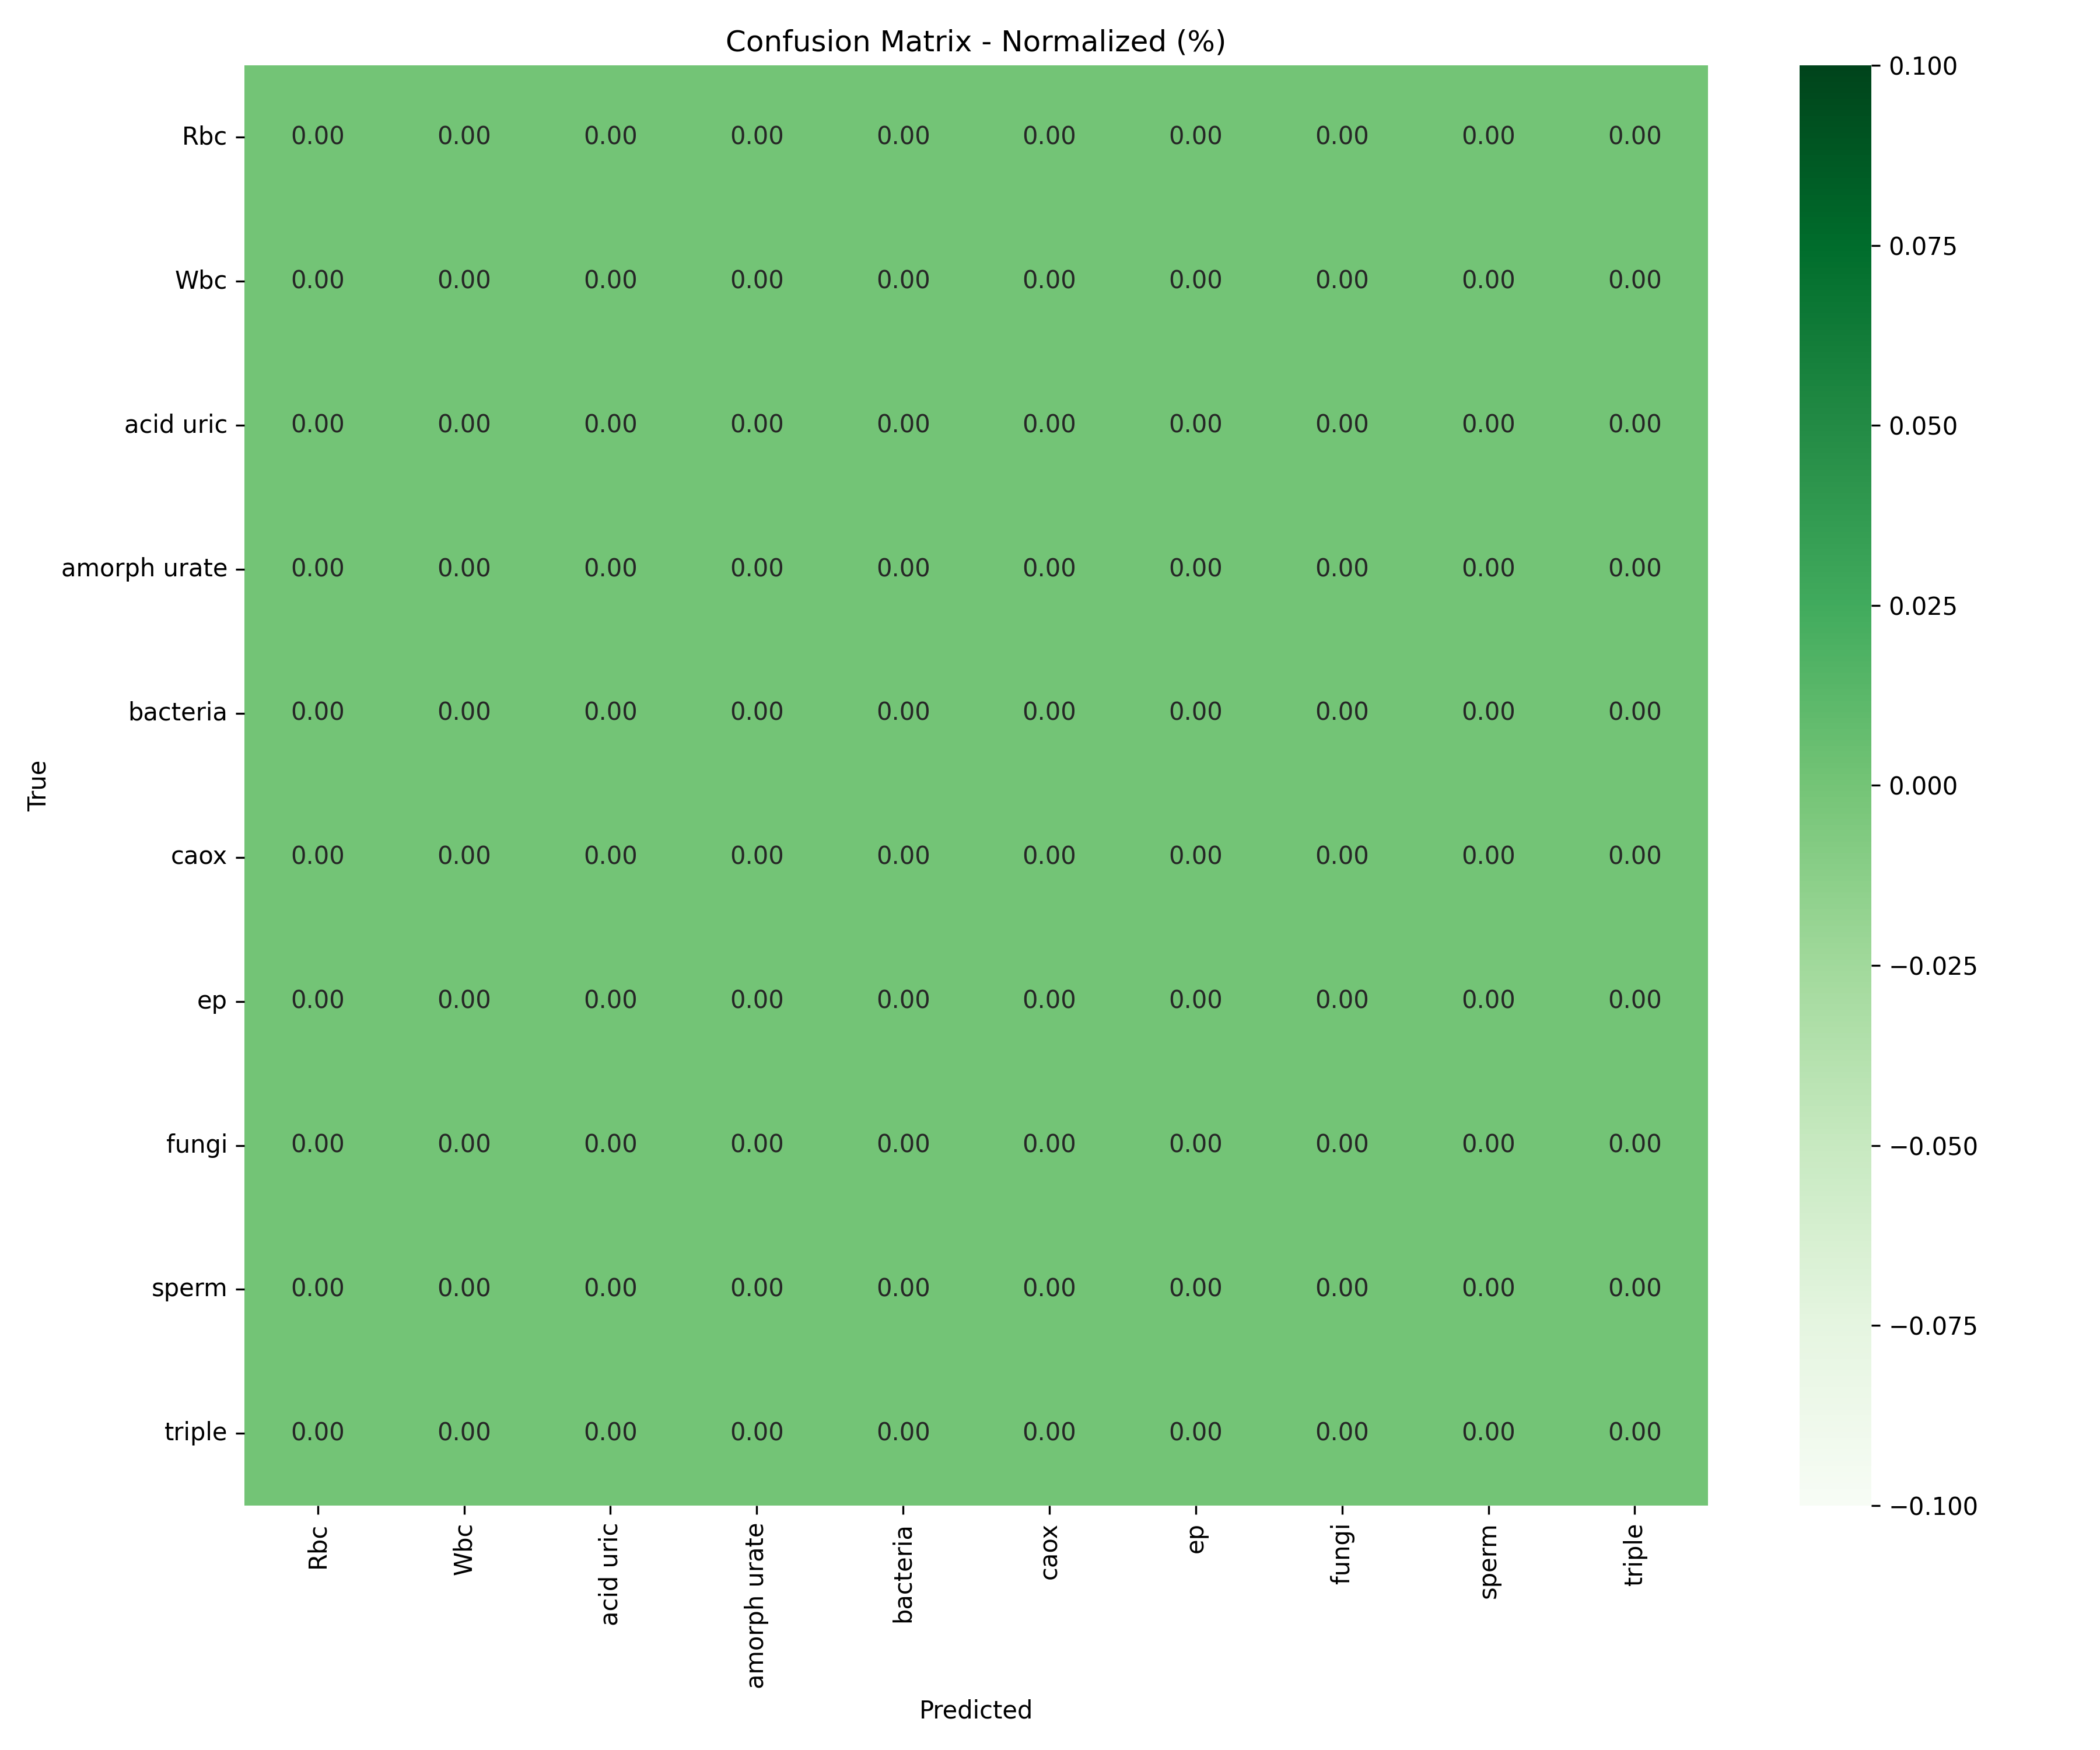

ValueError: Number of classes, 0, does not match size of target_names, 10. Try specifying the labels parameter

In [22]:
import matplotlib
matplotlib.use('Agg')  

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
from sklearn.metrics import confusion_matrix, classification_report
from IPython.display import Image, display 


class_names = ['Rbc','Wbc','acid uric','amorph urate','bacteria','caox','ep','fungi','sperm','triple']
save_dir = "/content/drive/MyDrive/results_cm"
os.makedirs(save_dir, exist_ok=True)


cm = confusion_matrix(y_true, y_pred, labels=list(range(len(class_names))))
cm_percent = cm.astype(float) / cm.sum(axis=1, keepdims=True)
cm_percent = np.nan_to_num(cm_percent) * 100

# رسم و ذخیره (counts)
plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix - Counts")
plt.tight_layout()
path_counts = os.path.join(save_dir, "CM_counts.png")
plt.savefig(path_counts, dpi=300)
plt.close()

# رسم و ذخیره (percent)
plt.figure(figsize=(12,10))
sns.heatmap(cm_percent, annot=True, fmt=".2f", cmap="Greens", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted"); plt.ylabel("True"); plt.title("Confusion Matrix - Normalized (%)")
plt.tight_layout()
path_percent = os.path.join(save_dir, "CM_percent.png")
plt.savefig(path_percent, dpi=300)
plt.close()


print("Saved:", path_counts, path_percent)
display(Image(path_counts))
display(Image(path_percent))

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
with open(os.path.join(save_dir, "classification_report.txt"), "w") as f:
    f.write(report)
print(report)
